In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("Ready")

Ready


In [3]:
# Use 10 years of SPY for a robust backtest
df = yf.download("SPY", start="2010-01-01",
                 end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
price = df["Close"].squeeze()
log_returns = np.log(price / price.shift(1)).dropna()

print(f"Loaded {len(price)} trading days")
print(f"Date range: {price.index[0].date()} to {price.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed

Loaded 3522 trading days
Date range: 2010-01-04 to 2023-12-29


In [4]:
# Calculate moving averages
sma50 = price.rolling(50).mean()
sma200 = price.rolling(200).mean()

# Signal: 1 when SMA50 > SMA200, 0 otherwise
signal = (sma50 > sma200).astype(int)

# Shift by 1 - avoid lookahead bias
# Signal seen at today's close, acted on tomorrow
position = signal.shift(1).fillna(0)

# Count signals
trades = position.diff().abs().fillna(0)
n_trades = int(trades.sum())

print(f"Total position changes : {n_trades}")
print(f"Avg trades per year : {n_trades/14:.1f}")
print(f"Current position : {'LONG' if position.iloc[-1] == 1 else 'FLAT'}")

Total position changes : 13
Avg trades per year : 0.9
Current position : LONG


In [6]:
# Align returns with position
log_returns_aligned = log_returns.reindex(position.index).fillna(0)

# Strategy returns = position * market returns
strategy_returns = position * log_returns_aligned

# Transaction costs - charged on every position change
cost_per_trade = 0.006 # 0.06% round trip from Day 3
costs = trades * cost_per_trade

# Net_returns after costs
net_returns = strategy_returns - costs

# Equity curves
strategy_equity = (1 + net_returns).cumprod()
bh_equity = (1 + log_returns_aligned).cumprod()

print(f"Strategy final value : ${strategy_equity.iloc[-1]:.2f}")
print(f"Buy & Hold final value: ${bh_equity.iloc[-1]:.2f}")
print(f"\n(Starting from $1.00)")

Strategy final value : $2.53
Buy & Hold final value: $4.41

(Starting from $1.00)


In [7]:
def performance_summary(returns, name):
    ann_ret = returns.mean() * 252
    ann_vol = returns.std()  * np.sqrt(252)
    sharpe  = (ann_ret - 0.02) / ann_vol
    wealth  = (1 + returns).cumprod()
    dd      = (wealth - wealth.cummax()) / wealth.cummax()
    max_dd  = dd.min()
    return {
        "name"    : name,
        "ann_ret" : ann_ret,
        "ann_vol" : ann_vol,
        "sharpe"  : sharpe,
        "max_dd"  : max_dd
    }

strat = performance_summary(net_returns,          "SMA 50/200")
bh    = performance_summary(log_returns_aligned,  "Buy & Hold")

print(f"\n{'='*58}")
print(f"  {'Strategy':<20} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9}")
print(f"{'='*58}")
for r in [strat, bh]:
    print(f"  {r['name']:<20} {r['ann_ret']:>8.2%} {r['ann_vol']:>8.2%} {r['sharpe']:>7.2f} {r['max_dd']:>9.2%}")
print(f"{'='*58}")


  Strategy              Ann Ret  Ann Vol  Sharpe    Max DD
  SMA 50/200              7.60%   13.83%    0.40   -35.75%
  Buy & Hold             12.14%   17.38%    0.58   -35.75%


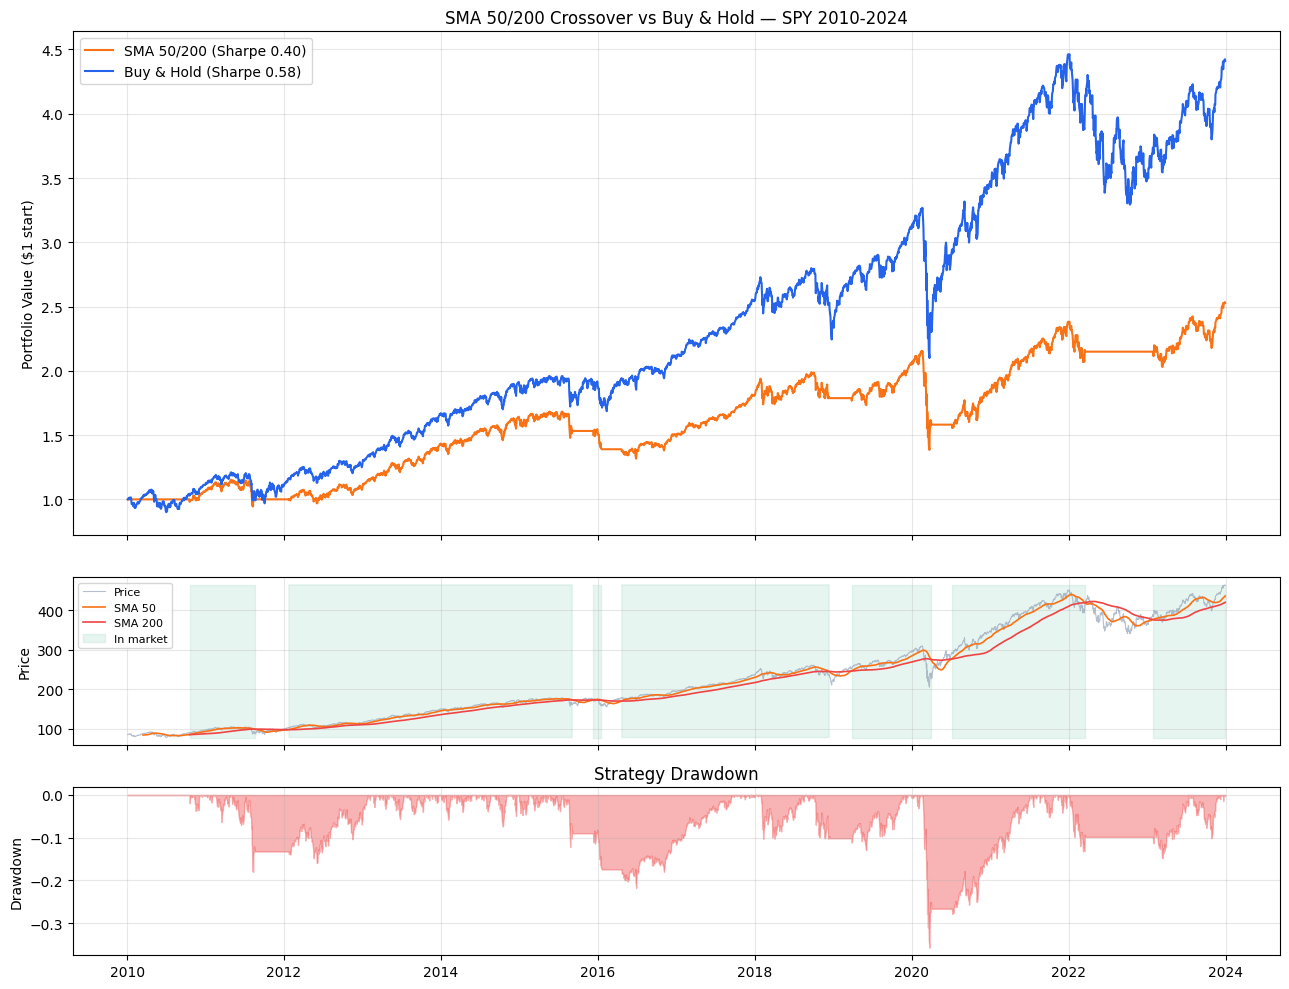

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 10),
    gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)

# Panel 1: Equity curves
ax1.plot(strategy_equity, color='#f97316', lw=1.5,
         label=f'SMA 50/200 (Sharpe {strat["sharpe"]:.2f})')
ax1.plot(bh_equity,       color='#2563eb', lw=1.5,
         label=f'Buy & Hold (Sharpe {bh["sharpe"]:.2f})')
ax1.set_title('SMA 50/200 Crossover vs Buy & Hold — SPY 2010-2024')
ax1.set_ylabel('Portfolio Value ($1 start)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: SMA lines with signals
ax2.plot(price,  color='#94a3b8', lw=0.8, alpha=0.7, label='Price')
ax2.plot(sma50,  color='#f97316', lw=1.2, label='SMA 50')
ax2.plot(sma200, color='#ef4444', lw=1.2, label='SMA 200')
ax2.fill_between(position.index, price.min(), price.max(),
                 where=(position==1), alpha=0.1, color='#1D9E75',
                 label='In market')
ax2.set_ylabel('Price')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Panel 3: Drawdown
wealth_s = (1 + net_returns).cumprod()
dd_s = (wealth_s - wealth_s.cummax()) / wealth_s.cummax()
ax3.fill_between(dd_s.index, dd_s, 0,
                 color='#ef4444', alpha=0.4)
ax3.set_title('Strategy Drawdown')
ax3.set_ylabel('Drawdown')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
def sma_backtest(ticker, fast=50, slow=200,
                 start="2010-01-01", end="2024-01-01",
                 cost_pct=0.0006):
    """
    SMA crossover backtest with costs and benchmark comparison.
    Returns performance dict.
    """
    # Data
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    price = df["Close"].squeeze()
    log_ret = np.log(price / price.shift(1)).dropna()

    # Signals
    sma_fast = price.rolling(fast).mean()
    sma_slow = price.rolling(slow).mean()
    position = (sma_fast > sma_slow).astype(int).shift(1).fillna(0)

    # Returns
    log_ret_aligned = log_ret.reindex(position.index).fillna(0)
    strat_ret       = position * log_ret_aligned
    trades          = position.diff().abs().fillna(0)
    net_ret         = strat_ret - (trades * cost_pct)

    # Metrics
    def metrics(r):
        ar = r.mean() * 252
        av = r.std()  * np.sqrt(252)
        sh = (ar - 0.02) / av
        w  = (1 + r).cumprod()
        dd = (w - w.cummax()) / w.cummax()
        return ar, av, sh, dd.min()

    s_ar, s_av, s_sh, s_dd = metrics(net_ret)
    b_ar, b_av, b_sh, b_dd = metrics(log_ret_aligned)

    print(f"\n{'='*58}")
    print(f"  {ticker} SMA {fast}/{slow} BACKTEST")
    print(f"{'='*58}")
    print(f"  {'Strategy':<20} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9}")
    print(f"  {'-'*54}")
    print(f"  {'SMA Strategy':<20} {s_ar:>8.2%} {s_av:>8.2%} {s_sh:>7.2f} {s_dd:>9.2%}")
    print(f"  {'Buy & Hold':<20} {b_ar:>8.2%} {b_av:>8.2%} {b_sh:>7.2f} {b_dd:>9.2%}")
    print(f"{'='*58}")
    print(f"  Total trades: {int(trades.sum())} over {len(log_ret)/252:.0f} years")

    return {"sharpe": s_sh, "ann_ret": s_ar,
            "max_dd": s_dd, "n_trades": int(trades.sum())}

# Test on SPY and AAPL
sma_backtest("SPY",  fast=50, slow=200)
sma_backtest("AAPL", fast=50, slow=200)

[*********************100%***********************]  1 of 1 completed



  SPY SMA 50/200 BACKTEST
  Strategy              Ann Ret  Ann Vol  Sharpe    Max DD
  ------------------------------------------------------
  SMA Strategy            8.10%   13.81%    0.44   -35.75%
  Buy & Hold             12.14%   17.38%    0.58   -35.75%
  Total trades: 13 over 14 years


[*********************100%***********************]  1 of 1 completed


  AAPL SMA 50/200 BACKTEST
  Strategy              Ann Ret  Ann Vol  Sharpe    Max DD
  ------------------------------------------------------
  SMA Strategy           18.57%   23.81%    0.70   -46.89%
  Buy & Hold             24.27%   28.21%    0.79   -45.94%
  Total trades: 11 over 14 years


{'sharpe': np.float64(0.6958962253506061),
 'ann_ret': np.float64(0.1856936152624989),
 'max_dd': np.float64(-0.4688849981105539),
 'n_trades': 11}